# Устойчивость переноса спектрального параметра

Воспроизводимый отчёт использует пакетный API `em3d`; численные алгоритмы не определяются внутри блокнота.

## 1. Конфигурация

In [1]:
from pathlib import Path
import sys

for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "src" / "em3d").is_dir():
        sys.path.insert(0, str(candidate / "src"))
        sys.path.insert(0, str(candidate))
        REPOSITORY_ROOT = candidate
        break
else:
    raise RuntimeError("Не найден корень репозитория em3d")

from IPython.display import display
import pandas as pd

from em3d.experiments.spectral_transfer import default_article_cases
from experiments.em_spectral import SpectralStudyConfig, run_spectral_transfer_study
from experiments.em_spectral.plots import (
    plot_spectral_localizations,
    plot_transfer_bounds,
    plot_residual_histories,
)

In [2]:
RUN_FINE = False
RUN_ARNOLDI = False
OUTPUT_ROOT = REPOSITORY_ROOT / 'outputs/em_spectral_transfer/notebook-quick'
config = SpectralStudyConfig.quick(output_root=OUTPUT_ROOT, device='cpu')
config

SpectralStudyConfig(mode='quick', grids=GridHierarchyConfig(coarse_sizes=(2, 3), control_size=4, fine_size=8), iteration=IterationStudyConfig(max_iter=120, rtol=1e-07, divergence_guard=1000000.0), arnoldi=ArnoldiConfig(krylov_dimension=20, milestones=(5, 10, 15, 20), seed=20260909, breakdown_tolerance=1e-13, reorthogonalization_passes=2, store_hessenberg=True), runtime=RuntimeConfig(device='cpu', precision='double', random_seed=20260908), eigenvalue_repeats=1, output_root=PosixPath('/mnt/data/em3d_refactor/outputs/em_spectral_transfer/notebook-quick'))

## 2. Выполнение воспроизводимого сценария

In [3]:
study = run_spectral_transfer_study(
    config,
    cases=default_article_cases(),
    include_fine=RUN_FINE,
    include_arnoldi=RUN_ARNOLDI,
)
study.output_root

'/mnt/data/em3d_refactor/outputs/em_spectral_transfer/notebook-quick'

## 3. Контроль плотного и БПФ-действий

In [4]:
consistency = pd.DataFrame([
    {
        'case': case.definition.key,
        'relative_dense_fft_error': case.operator_consistency_error,
    }
    for case in study.cases
])
display(consistency)

,case,relative_dense_fft_error
0,homogeneous_anisotropic,1.987390e-16
1,anisotropic_ellipsoid,0.000000e+00
2,local_inclusion,1.509787e-16


## 4. Спектральные локализации и оценка переноса

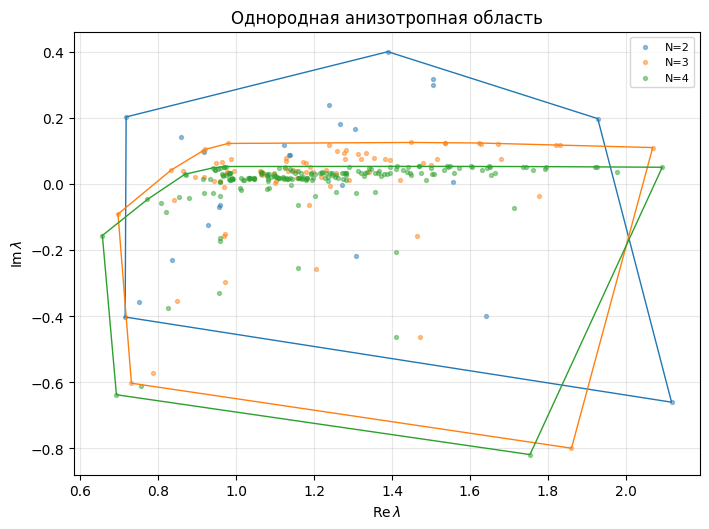

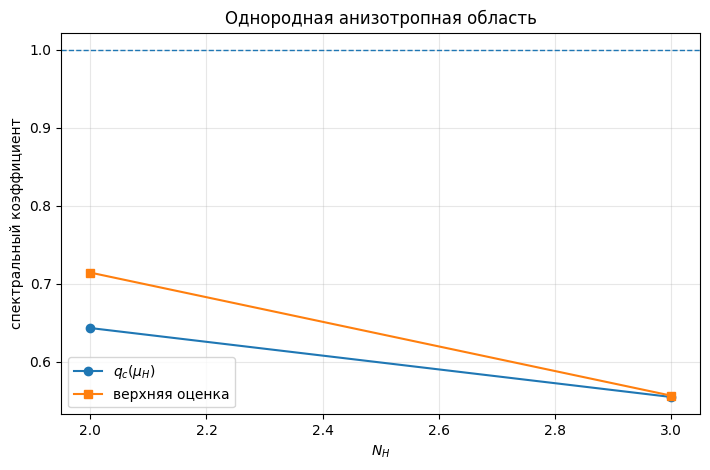

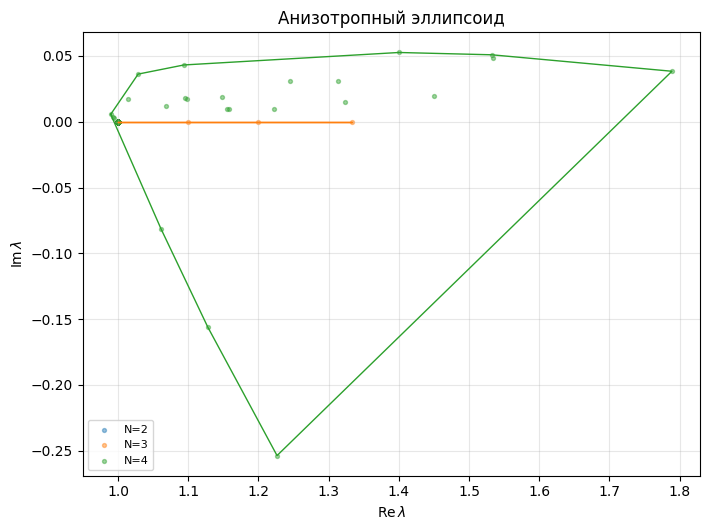

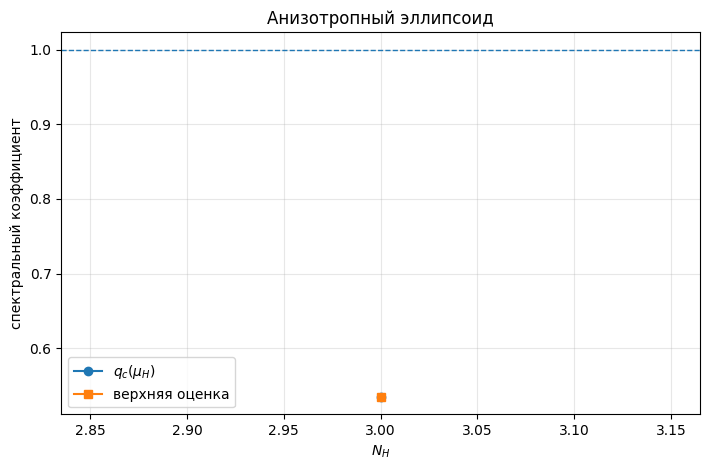

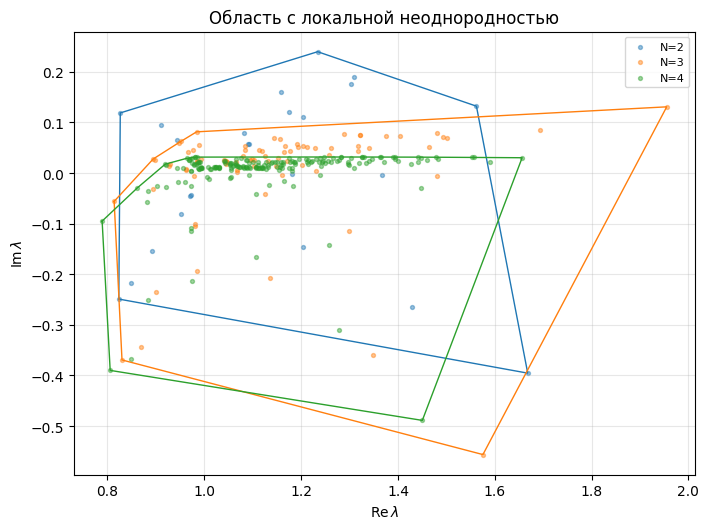

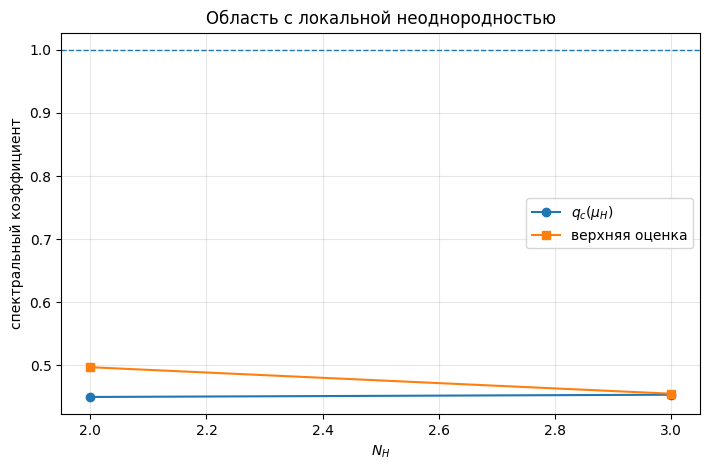

In [5]:
for case in study.cases:
    plot_spectral_localizations(case)
    plot_transfer_bounds(case)

## 5. Рабочая сетка

In [6]:
if RUN_FINE:
    for case in study.cases:
        plot_residual_histories(case)
else:
    print('Крупносеточный этап отключён; установите RUN_FINE=True.')

Крупносеточный этап отключён; установите RUN_FINE=True.


## 6. Артефакты

In [7]:
sorted(str(path.relative_to(OUTPUT_ROOT)) for path in OUTPUT_ROOT.rglob('*') if path.is_file())

['config.json',
 'manifest.json',
 'raw/spectra/anisotropic_ellipsoid_N2.npz',
 'raw/spectra/anisotropic_ellipsoid_N3.npz',
 'raw/spectra/anisotropic_ellipsoid_N4.npz',
 'raw/spectra/homogeneous_anisotropic_N2.npz',
 'raw/spectra/homogeneous_anisotropic_N3.npz',
 'raw/spectra/homogeneous_anisotropic_N4.npz',
 'raw/spectra/local_inclusion_N2.npz',
 'raw/spectra/local_inclusion_N3.npz',
 'raw/spectra/local_inclusion_N4.npz',
 'tables/control_transfers.csv',
 'tables/operator_consistency.csv',
 'tables/spectral_localizations.csv']